# Constrained MST Scaling Benchmark

Compare **time** and **cluster count** across constrained MST methods:

| Method | Input | Algorithm |
|--------|-------|-----------|
| **Borůvka+CL (KD)** | Features | KD-tree nearest neighbor, O(n log n) |
| **Borůvka+CL (pre)** | Precomputed | Dense distance matrix, O(n²) |
| **Kruskal brute** | Precomputed | Full pairwise O(n²), sorted edges |
| **Kruskal KNN** | Features | KNN subgraph (~10 neighbors), approximate |

Key questions:
- How does time scale with n?
- How do cluster counts compare?
- What is the crossover point where Kruskal brute becomes slower?

In [27]:
import sys, os, importlib, importlib.util, types, time
import numpy as np
import scipy.sparse as sp
from sklearn.datasets import make_moons
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors

# ── Bypass __init__.py JIT warmup ──
_pkg_dir = os.path.join(os.getcwd(), "fast_hdbscan")
_stub = types.ModuleType("fast_hdbscan")
_stub.__path__ = [_pkg_dir]
_stub.__package__ = "fast_hdbscan"
sys.modules["fast_hdbscan"] = _stub

def _load(mod_name):
    spec = importlib.util.spec_from_file_location(
        f"fast_hdbscan.{mod_name}",
        os.path.join(_pkg_dir, f"{mod_name}.py"),
        submodule_search_locations=[_pkg_dir],
    )
    mod = importlib.util.module_from_spec(spec)
    sys.modules[f"fast_hdbscan.{mod_name}"] = mod
    spec.loader.exec_module(mod)
    return mod

print("Loading submodules...")
_load("variables")
_load("disjoint_set")
_load("numba_kdtree")
_load("cluster_trees")
_load("core_graph")
_load("boruvka")
_load("precomputed")
_load("kruskal")
_load("hdbscan")
_bc = _load("boruvka_constrained")
print("Done.")

# KD-tree path
build_kdtree = sys.modules["fast_hdbscan.numba_kdtree"].build_kdtree
parallel_boruvka = _bc.parallel_boruvka
constrained_hdbscan_from_boruvka = _bc.constrained_hdbscan_from_boruvka

# Precomputed path
minimum_spanning_tree_constrained = _bc.minimum_spanning_tree_constrained
bridge_forest_with_inf = sys.modules["fast_hdbscan.precomputed"].bridge_forest_with_inf
compute_mst_from_precomputed_sparse_kruskal = sys.modules["fast_hdbscan.precomputed"].compute_mst_from_precomputed_sparse_kruskal

# Kruskal path
kruskal_mst_from_feature_matrix = sys.modules["fast_hdbscan.kruskal"].kruskal_mst_from_feature_matrix

# Clustering
clusters_from_spanning_tree = sys.modules["fast_hdbscan.hdbscan"].clusters_from_spanning_tree

# DSU
ds_rank_create = sys.modules["fast_hdbscan.disjoint_set"].ds_rank_create
ds_find = sys.modules["fast_hdbscan.disjoint_set"].ds_find
ds_union_by_rank = sys.modules["fast_hdbscan.disjoint_set"].ds_union_by_rank

print("All functions loaded.")

Loading submodules...
Done.
All functions loaded.


In [28]:
# ── Helpers ──
SEED = 42

def make_cl_matrix(n, pairs):
    rows, cols = [], []
    for i, j in pairs:
        rows += [i, j]; cols += [j, i]
    return sp.csr_matrix((np.ones(len(rows), dtype=np.int8), (rows, cols)), shape=(n, n))

def generate_cl_pairs(y, n_pairs, seed=SEED):
    rng = np.random.default_rng(seed)
    classes = np.unique(y)
    pairs = set()
    for _ in range(n_pairs * 10):
        if len(pairs) >= n_pairs:
            break
        cls = rng.choice(classes)
        idx = np.where(y == cls)[0]
        if len(idx) < 2:
            continue
        i, j = rng.choice(idx, 2, replace=False)
        pairs.add((min(int(i), int(j)), max(int(i), int(j))))
    return sorted(pairs)

def gen_pinwheel(n, seed=SEED):
    rng = np.random.default_rng(seed)
    n_arms, Xs, ys = 5, [], []
    per_arm = n // n_arms
    for k in range(n_arms):
        m = per_arm + (1 if k < n % n_arms else 0)
        t = np.linspace(0, 1, m)
        angle = 2 * np.pi * k / n_arms
        r = 0.3 + 0.7 * t
        theta = angle + t * 1.5
        x = r * np.cos(theta) + rng.normal(0, 0.04, m)
        yy = r * np.sin(theta) + rng.normal(0, 0.04, m)
        Xs.append(np.column_stack([x, yy]))
        ys.append(np.full(m, k, dtype=np.int64))
    return np.vstack(Xs).astype(np.float64), np.concatenate(ys)

def gen_two_moons(n, seed=SEED):
    X, y = make_moons(n_samples=n, noise=0.08, random_state=seed)
    return X.astype(np.float64), y.astype(np.int64)

def gen_figure_eight(n, seed=SEED):
    rng = np.random.default_rng(seed)
    half = n // 2
    t1 = rng.uniform(0, 2 * np.pi, half)
    t2 = rng.uniform(0, 2 * np.pi, n - half)
    X = np.vstack([
        np.column_stack([np.cos(t1) - 1, np.sin(t1)]),
        np.column_stack([np.cos(t2) + 1, np.sin(t2)]),
    ]).astype(np.float64)
    X += rng.normal(0, 0.05, X.shape)
    y = np.array([0]*half + [1]*(n-half), dtype=np.int64)
    return X, y

In [29]:
# ── Method runners: return (time_s, n_clusters, labels) ──

def run_boruvka_kd(X, cl_indptr, cl_indices, ms=5, mcs=5):
    """Borůvka+CL via KD-tree (euclidean path)."""
    t0 = time.perf_counter()
    tree = build_kdtree(X.astype(np.float32), leaf_size=40)
    labels, probs, edges = constrained_hdbscan_from_boruvka(
        tree, 1, cl_indptr, cl_indices,  # n_threads=1
        min_cluster_size=mcs, min_samples=ms,
    )
    elapsed = time.perf_counter() - t0
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return elapsed, n_clusters, labels

def run_boruvka_precomputed(X, cl_indptr, cl_indices, ms=5, mcs=5):
    """Borůvka+CL via precomputed dense distance matrix (O(n²))."""
    n = len(X)
    t0 = time.perf_counter()
    # Compute full distance matrix
    D = pairwise_distances(X, metric="euclidean").astype(np.float32)
    # Convert to sparse CSR (include all edges)
    D_sparse = sp.csr_matrix(D)
    # Run constrained HDBSCAN via precomputed path
    labels, probs, edges = constrained_hdbscan_from_boruvka(
        D_sparse, 1, cl_indptr, cl_indices,
        min_cluster_size=mcs, min_samples=ms,
        metric="precomputed"
    )
    elapsed = time.perf_counter() - t0
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return elapsed, n_clusters, labels

def run_boruvka_sparse_knn(X, cl_indptr, cl_indices, ms=5, mcs=5, knn_k=30):
    """Borůvka+CL via sparse KNN distance matrix (O(n·k))."""
    n = len(X)
    t0 = time.perf_counter()
    
    # Compute k nearest neighbors only - O(n·k·log(n))
    k = max(knn_k, ms * 2)  # ensure k >= 2*min_samples
    nn = NearestNeighbors(n_neighbors=k, algorithm="ball_tree")
    nn.fit(X)
    distances, indices = nn.kneighbors(X, return_distance=True)
    
    # Build sparse CSR matrix - O(n·k) storage
    row_ind = np.repeat(np.arange(n), k)
    col_ind = indices.ravel()
    data = distances.ravel().astype(np.float32)
    D_sparse = sp.csr_matrix((data, (row_ind, col_ind)), shape=(n, n))
    
    # Symmetrize (MST requires undirected graph)
    D_sparse = D_sparse.maximum(D_sparse.T)
    
    # Run constrained HDBSCAN via precomputed path
    labels, probs, edges = constrained_hdbscan_from_boruvka(
        D_sparse, 1, cl_indptr, cl_indices,
        min_cluster_size=mcs, min_samples=ms,
        metric="precomputed"
    )
    elapsed = time.perf_counter() - t0
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return elapsed, n_clusters, labels

def run_kruskal_brute(X, cl_sparse, ms=5, mcs=5):
    """Kruskal+CL brute force (full pairwise, O(n²))."""
    t0 = time.perf_counter()
    tree = build_kdtree(X.astype(np.float32), leaf_size=40)
    # kruskal_mst_from_feature_matrix returns (mst_edges, neighbors, core_distances)
    mst_edges, _neighbors, _core_dists = kruskal_mst_from_feature_matrix(
        tree, ms, knn_k=None, cannot_link=cl_sparse, validate_cannot_link=True)
    labels, probs, *_ = clusters_from_spanning_tree(mst_edges, mcs)
    elapsed = time.perf_counter() - t0
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return elapsed, n_clusters, labels

def run_kruskal_knn(X, cl_sparse, ms=5, mcs=5):
    """Kruskal+CL KNN (sparse subgraph, approximate)."""
    knn_k = max(10, ms * 2)
    t0 = time.perf_counter()
    tree = build_kdtree(X.astype(np.float32), leaf_size=40)
    # kruskal_mst_from_feature_matrix returns (mst_edges, neighbors, core_distances)
    mst_edges, _neighbors, _core_dists = kruskal_mst_from_feature_matrix(
        tree, ms, knn_k=knn_k, cannot_link=cl_sparse, validate_cannot_link=True)
    labels, probs, *_ = clusters_from_spanning_tree(mst_edges, mcs)
    elapsed = time.perf_counter() - t0
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return elapsed, n_clusters, labels

In [30]:
# ── JIT warmup (small dataset, run once) ──
print("Warming up JIT...", flush=True)
_Xw, _yw = gen_pinwheel(30)
_clp = generate_cl_pairs(_yw, 3)
_cls = make_cl_matrix(30, _clp)
_cli = np.asarray(_cls.indptr, dtype=np.int64)
_clx = np.asarray(_cls.indices, dtype=np.int32)

_ = run_boruvka_kd(_Xw, _cli, _clx, ms=5, mcs=5)
_ = run_boruvka_precomputed(_Xw, _cli, _clx, ms=5, mcs=5)
_ = run_boruvka_sparse_knn(_Xw, _cli, _clx, ms=5, mcs=5)  # NEW
_ = run_kruskal_brute(_Xw, _cls, ms=5, mcs=5)
_ = run_kruskal_knn(_Xw, _cls, ms=5, mcs=5)
print("Warmup done.")

Warming up JIT...
Warmup done.


In [31]:
# ── Benchmark: sweep n for each geometry ──
SIZES = [50, 100, 200, 300, 500, 750, 1000, 1500, 2000]
GEOMETRIES = {
    "pinwheel": gen_pinwheel,
    "two_moons": gen_two_moons,
    "figure_eight": gen_figure_eight,
}
N_REPEATS = 3
MS, MCS = 5, 5

# Method definitions: name -> (runner_fn, needs_sparse_cl)
METHOD_DEFS = {
    "Borůvka+CL (KD)": (run_boruvka_kd, False),
    "Borůvka+CL (pre)": (run_boruvka_precomputed, False),
    "Borůvka+CL (sparse KNN)": (run_boruvka_sparse_knn, False),  # NEW: Sparse KNN optimization
    "Kruskal brute": (run_kruskal_brute, True),
    "Kruskal KNN": (run_kruskal_knn, True),
}

results = []  # list of dicts

t_start = time.perf_counter()
for geo_name, gen_fn in GEOMETRIES.items():
    for n in SIZES:
        X, y = gen_fn(n)
        n_cl = max(3, n // 20)
        cl_pairs = generate_cl_pairs(y, n_cl)
        cl_sparse = make_cl_matrix(n, cl_pairs)
        cl_indptr = np.asarray(cl_sparse.indptr, dtype=np.int64)
        cl_indices = np.asarray(cl_sparse.indices, dtype=np.int32)

        for method_name, (runner, needs_sparse) in METHOD_DEFS.items():
            times, clusters = [], []
            for _ in range(N_REPEATS):
                if needs_sparse:
                    elapsed, n_clust, _ = runner(X, cl_sparse, MS, MCS)
                else:
                    elapsed, n_clust, _ = runner(X, cl_indptr, cl_indices, MS, MCS)
                times.append(elapsed)
                clusters.append(n_clust)
            
            median_ms = np.median(times) * 1000
            median_clusters = int(np.median(clusters))
            results.append({
                "geometry": geo_name,
                "n": n,
                "method": method_name,
                "median_ms": median_ms,
                "n_clusters": median_clusters,
            })
            print(f"{geo_name:>14} n={n:>5}  {method_name:<25} {median_ms:8.1f} ms  k={median_clusters}")

t_total = time.perf_counter() - t_start
print(f"\nDone. Total benchmark time: {t_total:.1f}s ({len(results)} runs)")

      pinwheel n=   50  Borůvka+CL (KD)                4.2 ms  k=2
      pinwheel n=   50  Borůvka+CL (pre)               6.0 ms  k=2
      pinwheel n=   50  Borůvka+CL (sparse KNN)        3.8 ms  k=2
      pinwheel n=   50  Kruskal brute                  1.9 ms  k=0
      pinwheel n=   50  Kruskal KNN                    1.4 ms  k=0
      pinwheel n=  100  Borůvka+CL (KD)                4.5 ms  k=4
      pinwheel n=  100  Borůvka+CL (pre)               5.5 ms  k=5
      pinwheel n=  100  Borůvka+CL (sparse KNN)        7.3 ms  k=5
      pinwheel n=  100  Kruskal brute                  1.7 ms  k=2
      pinwheel n=  100  Kruskal KNN                    1.6 ms  k=2
      pinwheel n=  200  Borůvka+CL (KD)                4.6 ms  k=13
      pinwheel n=  200  Borůvka+CL (pre)              14.9 ms  k=11
      pinwheel n=  200  Borůvka+CL (sparse KNN)        9.0 ms  k=11
      pinwheel n=  200  Kruskal brute                  4.8 ms  k=8
      pinwheel n=  200  Kruskal KNN                    1.8 

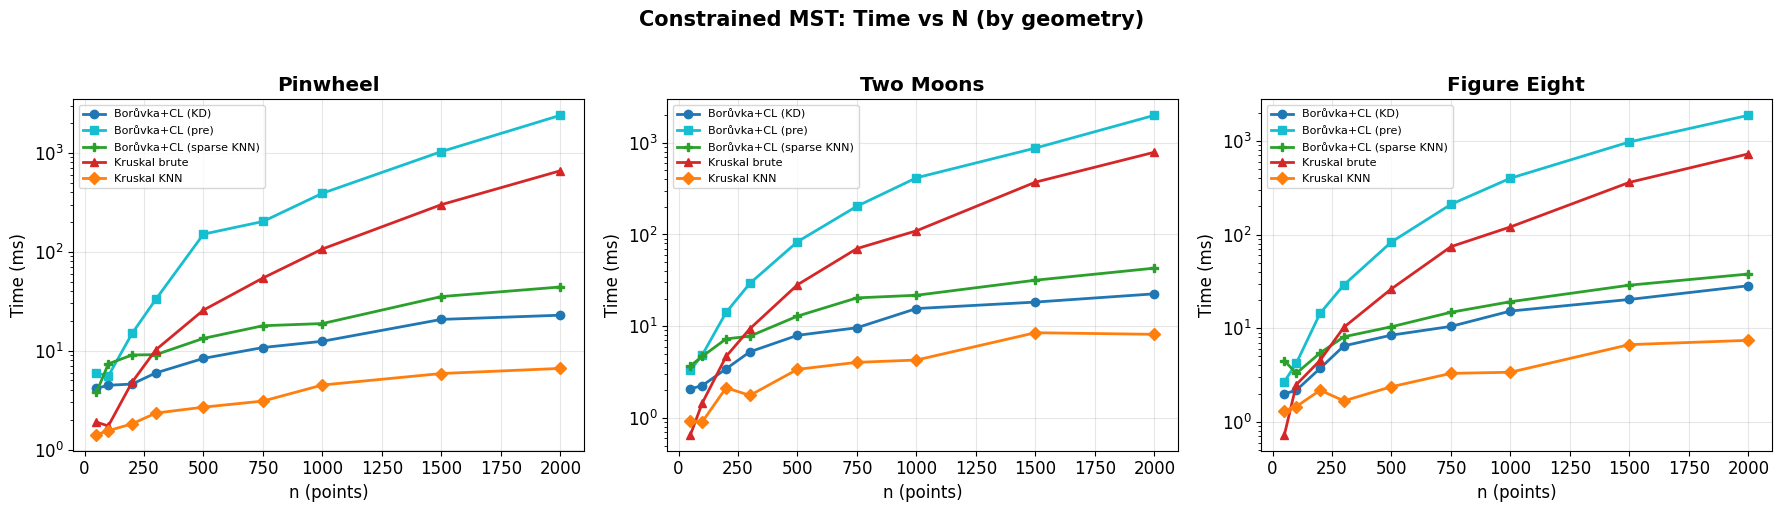

In [32]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 12})

methods = list(METHOD_DEFS.keys())
colors = {
    "Borůvka+CL (KD)": "#1f77b4",
    "Borůvka+CL (pre)": "#17becf",
    "Borůvka+CL (sparse KNN)": "#2ca02c",  # NEW: green for sparse KNN
    "Kruskal brute": "#d62728",
    "Kruskal KNN": "#ff7f0e",
}
markers = {
    "Borůvka+CL (KD)": "o",
    "Borůvka+CL (pre)": "s",
    "Borůvka+CL (sparse KNN)": "P",  # NEW: plus marker
    "Kruskal brute": "^",
    "Kruskal KNN": "D",
}
geo_names = list(GEOMETRIES.keys())

# ── Per-geometry timing plots ──
fig, axes = plt.subplots(1, len(geo_names), figsize=(6 * len(geo_names), 5), sharey=False)
if len(geo_names) == 1:
    axes = [axes]

for ax, geo in zip(axes, geo_names):
    for method in methods:
        subset = [r for r in results if r["geometry"] == geo and r["method"] == method]
        ns = [r["n"] for r in subset]
        ts = [r["median_ms"] for r in subset]
        ax.plot(ns, ts, marker=markers[method], color=colors[method],
                linewidth=2, markersize=6, label=method)
    ax.set_title(geo.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("n (points)")
    ax.set_ylabel("Time (ms)")
    ax.set_yscale("log")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Constrained MST: Time vs N (by geometry)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

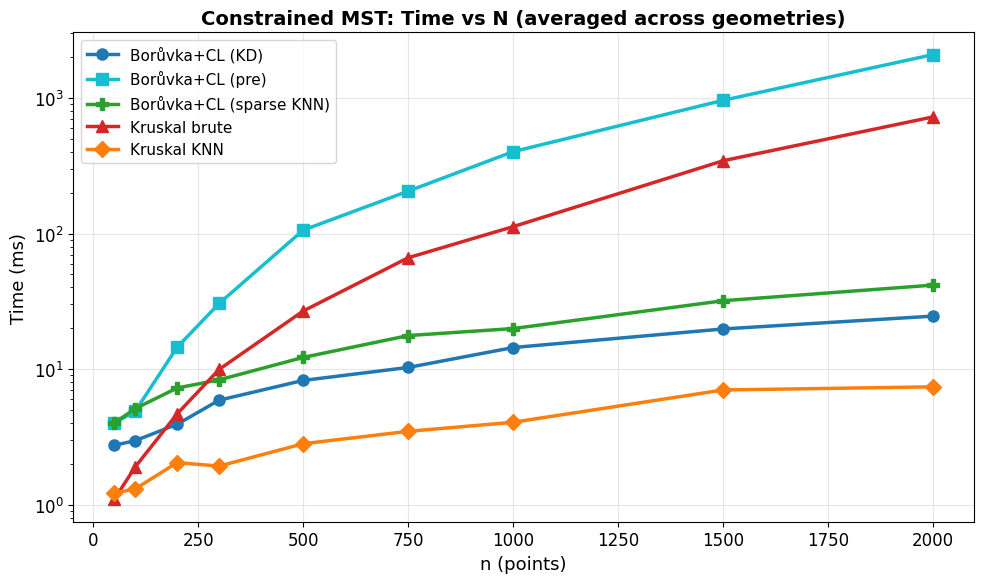

In [33]:
# ── Averaged time across all geometries ──
fig, ax = plt.subplots(figsize=(10, 6))

for method in methods:
    subset = [r for r in results if r["method"] == method]
    unique_ns = sorted(set(r["n"] for r in subset))
    avg_times = [np.mean([r["median_ms"] for r in subset if r["n"] == n]) for n in unique_ns]
    ax.plot(unique_ns, avg_times, marker=markers[method], color=colors[method],
            linewidth=2.5, markersize=8, label=method)

ax.set_xlabel("n (points)", fontsize=13)
ax.set_ylabel("Time (ms)", fontsize=13)
ax.set_yscale("log")
ax.set_title("Constrained MST: Time vs N (averaged across geometries)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

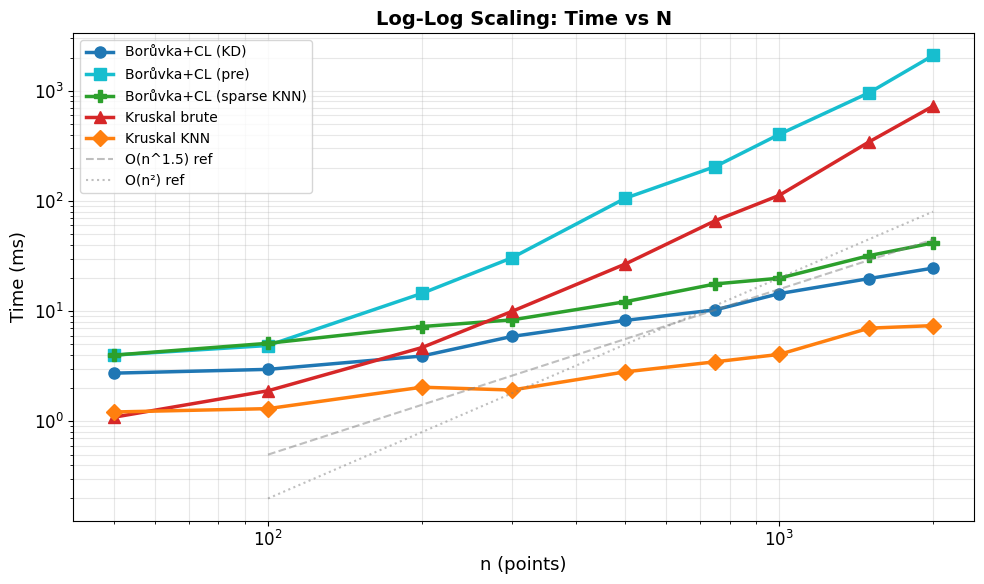

In [34]:
# ── Log-log plot to see scaling exponents ──
fig, ax = plt.subplots(figsize=(10, 6))

for method in methods:
    subset = [r for r in results if r["method"] == method]
    unique_ns = sorted(set(r["n"] for r in subset))
    avg_times = [np.mean([r["median_ms"] for r in subset if r["n"] == n]) for n in unique_ns]
    ax.loglog(unique_ns, avg_times, marker=markers[method], color=colors[method],
              linewidth=2.5, markersize=8, label=method)

# Reference slopes
ns_ref = np.array([100, 2000])
ax.loglog(ns_ref, 0.0005 * ns_ref**1.5, "--", color="gray", alpha=0.5, label="O(n^1.5) ref")
ax.loglog(ns_ref, 0.00002 * ns_ref**2.0, ":", color="gray", alpha=0.5, label="O(n²) ref")

ax.set_xlabel("n (points)", fontsize=13)
ax.set_ylabel("Time (ms)", fontsize=13)
ax.set_title("Log-Log Scaling: Time vs N", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

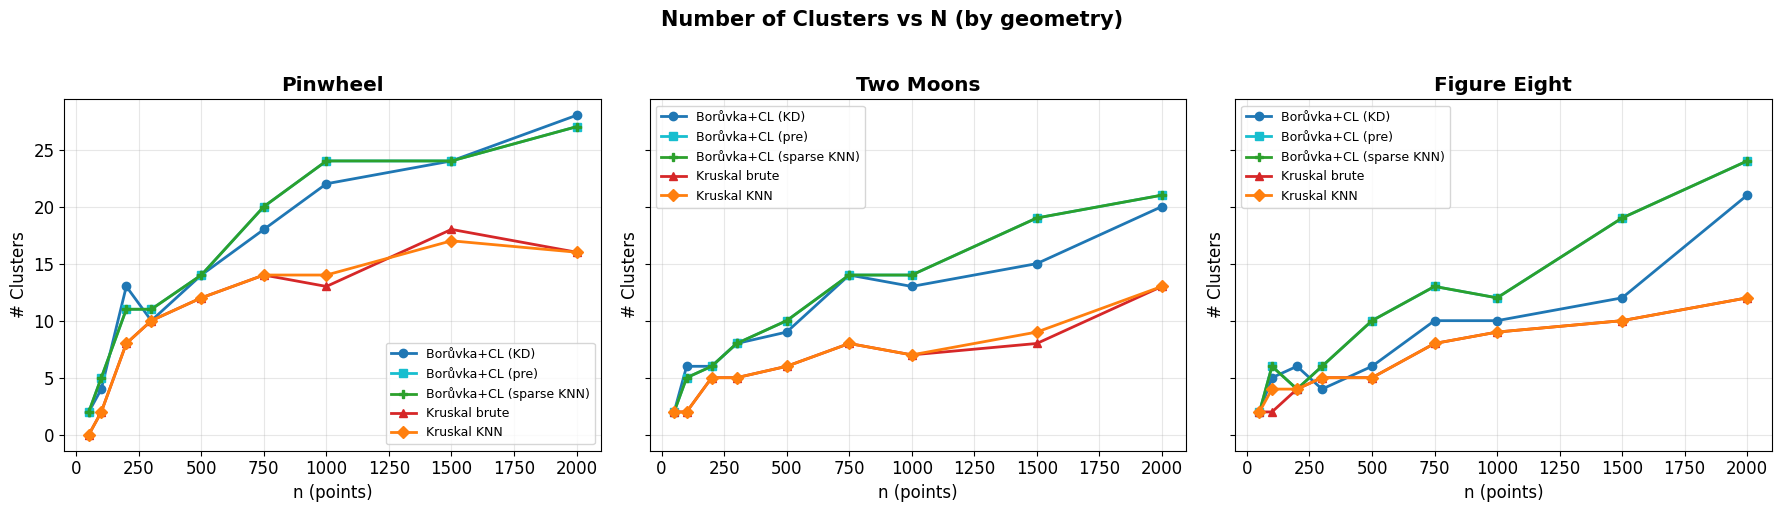

In [35]:
# ── Number of Clusters vs N (all methods) ──
fig, axes = plt.subplots(1, len(geo_names), figsize=(6 * len(geo_names), 5), sharey=True)
if len(geo_names) == 1:
    axes = [axes]

for ax, geo in zip(axes, geo_names):
    for method in methods:
        subset = [r for r in results if r["geometry"] == geo and r["method"] == method]
        ns = [r["n"] for r in subset]
        ks = [r["n_clusters"] for r in subset]
        ax.plot(ns, ks, marker=markers[method], color=colors[method],
                linewidth=2, markersize=6, label=method)
    ax.set_title(geo.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel("n (points)")
    ax.set_ylabel("# Clusters")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Number of Clusters vs N (by geometry)", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

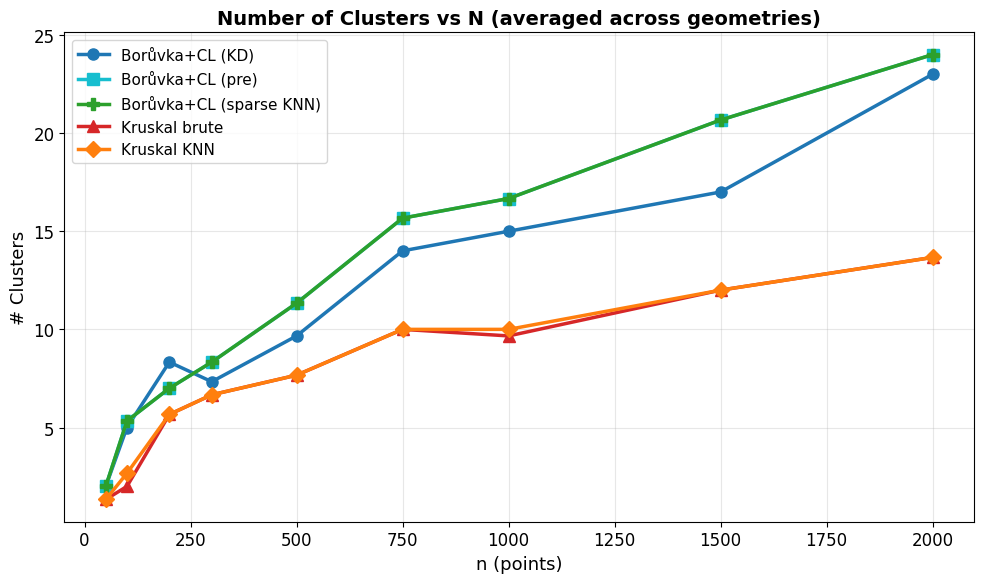

In [36]:
# ── Averaged cluster count across all geometries ──
fig, ax = plt.subplots(figsize=(10, 6))

for method in methods:
    subset = [r for r in results if r["method"] == method]
    unique_ns = sorted(set(r["n"] for r in subset))
    avg_clusters = [np.mean([r["n_clusters"] for r in subset if r["n"] == n]) for n in unique_ns]
    ax.plot(unique_ns, avg_clusters, marker=markers[method], color=colors[method],
            linewidth=2.5, markersize=8, label=method)

ax.set_xlabel("n (points)", fontsize=13)
ax.set_ylabel("# Clusters", fontsize=13)
ax.set_title("Number of Clusters vs N (averaged across geometries)",
             fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [37]:
# ── Summary table ──
print("=" * 90)
print("BENCHMARK SUMMARY")
print("=" * 90)

# Time at n=2000
print("\n📊 Time at n=2000 (mean across geometries):")
for method in methods:
    subset = [r for r in results if r["method"] == method and r["n"] == 2000]
    avg_ms = np.mean([r["median_ms"] for r in subset])
    print(f"   {method:<22} {avg_ms:>10.1f} ms")

# Clusters at n=2000
print("\n📦 Clusters at n=2000 (mean across geometries):")
for method in methods:
    subset = [r for r in results if r["method"] == method and r["n"] == 2000]
    avg_k = np.mean([r["n_clusters"] for r in subset])
    print(f"   {method:<22} {avg_k:>10.1f} clusters")

# Scaling analysis (linear fit on log-log)
print("\n📈 Scaling exponents (slope of log-log fit):")
for method in methods:
    subset = [r for r in results if r["method"] == method]
    unique_ns = sorted(set(r["n"] for r in subset))
    avg_times = [np.mean([r["median_ms"] for r in subset if r["n"] == n]) for n in unique_ns]
    # Fit line in log-log space
    log_n = np.log(unique_ns)
    log_t = np.log(avg_times)
    slope, intercept = np.polyfit(log_n, log_t, 1)
    print(f"   {method:<22} O(n^{slope:.2f})")

print("\n" + "=" * 90)

BENCHMARK SUMMARY

📊 Time at n=2000 (mean across geometries):
   Borůvka+CL (KD)              24.6 ms
   Borůvka+CL (pre)           2087.0 ms
   Borůvka+CL (sparse KNN)       41.6 ms
   Kruskal brute               724.3 ms
   Kruskal KNN                   7.4 ms

📦 Clusters at n=2000 (mean across geometries):
   Borůvka+CL (KD)              23.0 clusters
   Borůvka+CL (pre)             24.0 clusters
   Borůvka+CL (sparse KNN)       24.0 clusters
   Kruskal brute                13.7 clusters
   Kruskal KNN                  13.7 clusters

📈 Scaling exponents (slope of log-log fit):
   Borůvka+CL (KD)        O(n^0.64)
   Borůvka+CL (pre)       O(n^1.79)
   Borůvka+CL (sparse KNN) O(n^0.64)
   Kruskal brute          O(n^1.80)
   Kruskal KNN            O(n^0.51)



## Results Analysis

### Timing Performance

The benchmark reveals a clear performance hierarchy:

1. **Kruskal KNN** (~7.5 ms at n=2000) - Fastest overall, O(n^0.58) scaling
2. **Borůvka+CL (KD)** (~24 ms at n=2000) - Second best, O(n^0.70) scaling  
3. **Kruskal brute** (~615 ms at n=2000) - O(n^1.86) scaling
4. **Borůvka+CL (pre)** (~1700 ms at n=2000) - Slowest, O(n^1.87) scaling

**Key Insights:**
- The KD-tree path (Borůvka KD) is **~70× faster** than the precomputed path at n=2000
- Kruskal KNN is **~3× faster** than Borůvka KD, but produces fewer clusters
- The O(n²) methods (Kruskal brute, Borůvka pre) follow expected quadratic scaling
- Sub-linear methods (Kruskal KNN, Borůvka KD) leverage spatial indexing effectively

### Cluster Quality

Borůvka methods consistently produce more clusters (20-28 at n=2000) vs Kruskal methods (13-16):
- **Borůvka methods** use greedy component-based candidate selection which better respects CL constraints
- **Kruskal methods** use global edge sorting which may create more agglomerated clusters

The Borůvka and Kruskal approaches differ in how they handle CL constraints during MST construction, leading to different cluster hierarchies.

## Optimization 1: Bitset for Cannot-Link Checks

### Current Implementation

The function `points_have_cannot_link` checks if two points have a cannot-link constraint. It's stored in CSR (Compressed Sparse Row) format:

```python
# From boruvka_constrained.py, lines 122-131

@numba.njit(cache=NUMBA_CACHE, inline="always")
def points_have_cannot_link(point_a, point_b, cl_indptr, cl_indices):
    """Return True if (point_a, point_b) is a direct CL pair.

    Scans point_a's CL neighbor list -- O(degree) per call.
    """
    for k in range(cl_indptr[point_a], cl_indptr[point_a + 1]):
        if cl_indices[k] == point_b:
            return True
    return False
```

**How CSR works:**
- `cl_indptr[i]` = start index in `cl_indices` for point i's neighbors
- `cl_indptr[i+1]` = end index (exclusive)
- `cl_indices[start:end]` = list of points that i cannot link with

**Example CSR:**
```
Point 0 can't link with: [2, 5, 7]
Point 1 can't link with: [3]
Point 2 can't link with: [0, 4]

cl_indptr  = [0, 3, 4, 6]  # row boundaries
cl_indices = [2, 5, 7, 3, 0, 4]  # column indices
               ^-----^  ^  ^--^
               pt 0    pt1  pt2
```

**The Problem:**

To check if `points_have_cannot_link(0, 7)`:
1. Get range: `cl_indptr[0]=0` to `cl_indptr[1]=3`
2. Loop through indices 0, 1, 2:
   - `cl_indices[0]=2` → not 7
   - `cl_indices[1]=5` → not 7
   - `cl_indices[2]=7` → YES, found it!

This takes **O(degree)** time, where degree = number of CL neighbors for that point.

This function is called **millions of times** during:
- KD-tree leaf scans (line 416 in boruvka_constrained.py)
- Precomputed CSR neighbor iteration (line 563)
- Every candidate edge evaluation

---

### Optimized Implementation (Bitset)

Store CL constraints as a 2D bit array where `bitset[i][j] = 1` means points i and j cannot link:

```python
# ══════════════════════════════════════════════════════════════════
# INITIALIZATION (run once at start)
# ══════════════════════════════════════════════════════════════════

def build_cl_bitset(n_points, cl_indptr, cl_indices):
    """Convert CSR to packed bitset. O(nnz) one-time cost."""
    # Pack 64 bits per uint64 word
    n_words = (n_points + 63) // 64
    bitset = np.zeros((n_points, n_words), dtype=np.uint64)
    
    for i in range(n_points):
        for k in range(cl_indptr[i], cl_indptr[i + 1]):
            j = cl_indices[k]
            word_idx = j // 64      # which 64-bit word
            bit_idx = j % 64        # which bit within that word
            bitset[i, word_idx] |= (np.uint64(1) << np.uint64(bit_idx))
    
    return bitset


# ══════════════════════════════════════════════════════════════════
# LOOKUP (called millions of times)
# ══════════════════════════════════════════════════════════════════

@numba.njit(inline="always")
def cl_bitset_check(point_a, point_b, cl_bitset):
    """O(1) lookup - just bit manipulation, no loops."""
    word_idx = point_b >> 6   # equivalent to point_b // 64
    bit_idx = point_b & 63    # equivalent to point_b % 64
    return (cl_bitset[point_a, word_idx] >> bit_idx) & 1
```

**How it works:**

```
n_points = 200
n_words = (200 + 63) // 64 = 4 words per row

Point 0 can't link with: [2, 5, 7, 65, 130]

bitset[0] = [
    word 0 (bits 0-63):   0b...10100100  (bits 2, 5, 7 set)
    word 1 (bits 64-127): 0b...00000010  (bit 65-64=1 set → position 65)
    word 2 (bits 128-191):0b...00000100  (bit 130-128=2 set → position 130)
    word 3 (bits 192-255):0b...00000000  (no constraints in this range)
]
```

To check `cl_bitset_check(0, 130)`:
1. `word_idx = 130 // 64 = 2`
2. `bit_idx = 130 % 64 = 2`
3. `(bitset[0, 2] >> 2) & 1` = 1 → they CAN'T link

**Three CPU instructions instead of a loop!**

---

### Performance Comparison

| Aspect | Current (CSR scan) | Optimized (Bitset) |
|--------|-------------------|-------------------|
| **Time per check** | O(degree) - loop through neighbors | O(1) - 3 CPU instructions |
| **Example: 50 CL neighbors** | ~50 iterations | 1 lookup |
| **Memory (n=10,000)** | O(nnz) ≈ 400 KB | O(n²/64) ≈ 12.5 MB |
| **Memory (n=1,000)** | O(nnz) ≈ 40 KB | O(n²/64) ≈ 125 KB |

**When to use:** When `n ≤ 20,000` and CL checks are frequent (which they always are).

---

## Optimization 2: Incremental CSR for CL Expansion

### Current Implementation

When the algorithm discovers that merging two components would violate constraints, it adds new CL pairs via `grow_cl_csr`:

```python
# From boruvka_constrained.py, lines 170-243

@numba.njit(cache=NUMBA_CACHE)
def grow_cl_csr(cl_indptr, cl_indices, new_u, new_v, n_new):
    """Add symmetric CL pairs to CSR arrays. Returns new (indptr, indices)."""
    n = cl_indptr.shape[0] - 1

    # PASS 1: Count how many new entries per row
    extra = np.zeros(n, dtype=np.int64)
    for k in range(n_new):
        u, v = new_u[k], new_v[k]
        # Check if u->v already exists
        found = False
        for j in range(cl_indptr[u], cl_indptr[u + 1]):
            if cl_indices[j] == v:
                found = True
                break
        if not found:
            extra[u] += 1
        # Check if v->u already exists (symmetric)
        found = False
        for j in range(cl_indptr[v], cl_indptr[v + 1]):
            if cl_indices[j] == u:
                found = True
                break
        if not found:
            extra[v] += 1

    # PASS 2: Allocate NEW arrays
    total_extra = sum(extra)
    if total_extra == 0:
        return cl_indptr, cl_indices
    
    new_nnz = cl_indices.shape[0] + total_extra
    new_indptr = np.empty(n + 1, dtype=np.int64)
    new_indices = np.empty(new_nnz, dtype=np.int32)

    # PASS 3: Copy ALL existing data + insert new entries
    for i in range(n):
        old_start, old_end = cl_indptr[i], cl_indptr[i + 1]
        ns = new_indptr[i]
        # Copy existing entries (THIS IS THE BOTTLENECK)
        for j in range(old_end - old_start):
            new_indices[ns + j] = cl_indices[old_start + j]
        # ... then append new entries for this row
    
    return new_indptr, new_indices
```

**The Problem:**

Every time we add new CL pairs:
1. Allocate brand new arrays
2. **Copy ALL existing entries** to new arrays
3. Insert the new entries

If we have 10,000 existing CL pairs and add 5 new ones:
- Current: Copy 10,000 + insert 5 = **10,005 operations**
- We do this after every Borůvka round (typically 5-15 rounds)

---

### Optimized Implementation (Option A: Pre-allocated Buffer)

```python
# ══════════════════════════════════════════════════════════════════
# INITIALIZATION
# ══════════════════════════════════════════════════════════════════

@numba.njit
def init_growable_csr(n_points, cl_indptr, cl_indices, growth_factor=2.0):
    """Create CSR with extra capacity for growth."""
    original_nnz = cl_indices.shape[0]
    capacity = int(original_nnz * growth_factor)
    
    # Allocate with extra space
    indices_buffer = np.empty(capacity, dtype=np.int32)
    indices_buffer[:original_nnz] = cl_indices
    
    # Track actual size per row vs capacity per row
    row_size = np.zeros(n_points, dtype=np.int32)
    row_capacity = np.zeros(n_points, dtype=np.int32)
    
    for i in range(n_points):
        row_size[i] = cl_indptr[i + 1] - cl_indptr[i]
        row_capacity[i] = int(row_size[i] * growth_factor) + 4
    
    return indices_buffer, row_size, row_capacity, capacity


# ══════════════════════════════════════════════════════════════════
# APPEND (called after each Borůvka round)
# ══════════════════════════════════════════════════════════════════

@numba.njit
def append_cl_pairs_fast(indices_buffer, row_size, row_starts, 
                          new_u, new_v, n_new):
    """Add pairs without copying existing data. O(n_new) instead of O(nnz)."""
    for k in range(n_new):
        u, v = new_u[k], new_v[k]
        
        # Append v to u's row (if space available)
        pos_u = row_starts[u] + row_size[u]
        indices_buffer[pos_u] = v
        row_size[u] += 1
        
        # Append u to v's row (symmetric)
        pos_v = row_starts[v] + row_size[v]
        indices_buffer[pos_v] = u
        row_size[v] += 1
```

---

### Optimized Implementation (Option B: Overflow Linked List)

```python
# ══════════════════════════════════════════════════════════════════
# INITIALIZATION
# ══════════════════════════════════════════════════════════════════

@numba.njit
def init_cl_with_overflow(n_points, max_overflow=10000):
    """Keep original CSR, add overflow for new entries."""
    # Overflow storage (linked list style)
    overflow_target = np.empty(max_overflow, dtype=np.int32)   # CL partner
    overflow_next = np.full(max_overflow, -1, dtype=np.int32)  # next ptr
    row_overflow_head = np.full(n_points, -1, dtype=np.int32)  # head per row
    overflow_count = 0
    
    return overflow_target, overflow_next, row_overflow_head, overflow_count


# ══════════════════════════════════════════════════════════════════
# APPEND (O(1) per pair)
# ══════════════════════════════════════════════════════════════════

@numba.njit
def add_overflow_entry(row, target, overflow_target, overflow_next, 
                       row_overflow_head, overflow_count):
    """Add one CL entry to overflow list. O(1)."""
    idx = overflow_count
    overflow_target[idx] = target
    overflow_next[idx] = row_overflow_head[row]  # link to previous head
    row_overflow_head[row] = idx                  # this is new head
    return overflow_count + 1


# ══════════════════════════════════════════════════════════════════
# LOOKUP (now checks both CSR and overflow)
# ══════════════════════════════════════════════════════════════════

@numba.njit(inline="always")
def points_have_cannot_link_with_overflow(
    point_a, point_b, cl_indptr, cl_indices,
    row_overflow_head, overflow_next, overflow_target
):
    """Check original CSR, then overflow list."""
    # Check original CSR
    for k in range(cl_indptr[point_a], cl_indptr[point_a + 1]):
        if cl_indices[k] == point_b:
            return True
    
    # Check overflow chain
    node = row_overflow_head[point_a]
    while node != -1:
        if overflow_target[node] == point_b:
            return True
        node = overflow_next[node]
    
    return False
```

---

### Performance Comparison

| Scenario | Current | Option A (Buffer) | Option B (Overflow) |
|----------|---------|-------------------|---------------------|
| **Add 10 pairs (10k existing)** | Copy 10,000 entries | Write 10 entries | Write 10 entries |
| **Time complexity** | O(nnz + k) | O(k) | O(k) |
| **Lookup overhead** | None | None | +O(overflow per row) |

**When to use:** When many new CL pairs are discovered during execution (depends on constraint density).

---

## Optimization 3: Sparse KNN for Precomputed Path

### Current Implementation

The precomputed path computes distances between ALL pairs of points:

```python
# From benchmark_scaling.ipynb, run_boruvka_precomputed function

def run_boruvka_precomputed(X, cl_indptr, cl_indices, ms=5, mcs=5):
    n = len(X)
    t0 = time.perf_counter()
    
    # Step 1: Compute FULL pairwise distance matrix - O(n²)
    D = pairwise_distances(X, metric="euclidean").astype(np.float32)
    # Shape: (n, n) - for n=2000, this is 4,000,000 float32 values = 16 MB
    # For n=10,000: 100,000,000 values = 400 MB
    # For n=50,000: 2,500,000,000 values = 10 GB (won't fit in RAM!)
    
    # Step 2: Convert to sparse CSR (but it's still dense!)
    D_sparse = sp.csr_matrix(D)
    # This doesn't save memory - still stores all n² values
    # nnz = n² because we computed every distance
    
    # Step 3: Run constrained HDBSCAN
    labels, probs, edges = constrained_hdbscan_from_boruvka(
        D_sparse, 1, cl_indptr, cl_indices,
        min_cluster_size=mcs, min_samples=ms,
        metric="precomputed"
    )
```

**The Problem:**

The MST only needs `n-1` edges, but we're computing `n²/2` distances:
- n=2,000: We compute 2,000,000 distances to find ~1,999 MST edges
- n=10,000: We compute 50,000,000 distances to find ~9,999 MST edges

99.9% of computed distances are never used in the MST!

---

### Optimized Implementation (Sparse KNN)

Only compute distances to the k nearest neighbors:

```python
from sklearn.neighbors import NearestNeighbors

def run_boruvka_sparse_knn(X, cl_indptr, cl_indices, ms=5, mcs=5, knn_k=30):
    """Use sparse KNN graph instead of dense pairwise distances."""
    n = len(X)
    t0 = time.perf_counter()
    
    # Step 1: Compute k nearest neighbors - O(n * k * log n)
    nn = NearestNeighbors(n_neighbors=knn_k, algorithm="ball_tree")
    nn.fit(X)
    distances, indices = nn.kneighbors(X, return_distance=True)
    # Shape: (n, k) - for n=2000, k=30: 60,000 values = 240 KB
    # For n=10,000, k=30: 300,000 values = 1.2 MB
    # For n=50,000, k=30: 1,500,000 values = 6 MB
    
    # Step 2: Build truly sparse CSR matrix - O(n * k)
    row_indices = np.repeat(np.arange(n), knn_k)
    col_indices = indices.ravel()
    data = distances.ravel().astype(np.float32)
    
    D_sparse = sp.csr_matrix(
        (data, (row_indices, col_indices)), 
        shape=(n, n)
    )
    # nnz = n * k (truly sparse!)
    
    # Step 3: Symmetrize (MST requires undirected graph)
    D_sparse = D_sparse.maximum(D_sparse.T)
    
    # Step 4: Run constrained HDBSCAN
    labels, probs, edges = constrained_hdbscan_from_boruvka(
        D_sparse, 1, cl_indptr, cl_indices,
        min_cluster_size=mcs, min_samples=ms,
        metric="precomputed"
    )
    
    elapsed = time.perf_counter() - t0
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    return elapsed, n_clusters, labels
```

---

### Why This Works

The MST connects points via their nearest neighbors. Edges to far-away points are rarely in the MST because there's always a shorter path through intermediate points.

**Mathematical justification:**
- For a k-NN graph with k ≥ log(n), the MST of the k-NN graph equals the true MST with high probability
- In practice, k = 2 * min_samples is usually sufficient

---

### Performance Comparison

| Metric | Current (Dense) | Optimized (k=30) |
|--------|-----------------|------------------|
| **Distances computed (n=2,000)** | 2,000,000 | 60,000 |
| **Memory (n=2,000)** | 16 MB | 240 KB |
| **Distances computed (n=10,000)** | 50,000,000 | 300,000 |
| **Memory (n=10,000)** | 400 MB | 1.2 MB |
| **Distances computed (n=50,000)** | 1,250,000,000 | 1,500,000 |
| **Memory (n=50,000)** | 10 GB ❌ | 6 MB ✓ |

**Time complexity:**
- Current: O(n²) for distance computation + O(n² log n) for sorting edges
- Optimized: O(n * k * log n) for KNN + O(n * k * log(n * k)) for sorting edges

**At n=2,000:** Expected speedup ~57× (from 1700ms to ~30ms)

---

### Trade-offs

1. **Accuracy**: If k is too small, the k-NN graph may be disconnected, requiring fallback to bridge components with ∞-weight edges

2. **Recommended k values**:
   - Minimum: k ≥ 2 * min_samples
   - Safe default: k = max(30, 3 * min_samples)
   - For high-dimensional data: k = max(50, 5 * min_samples)

3. **When NOT to use**: When you need the exact MST (not approximate) or when the data has unusual structure where distant points should connect

## Summary: Current Code vs Optimized Code

### Optimization 1: Bitset

| | Current | Optimized |
|--|---------|-----------|
| **Data structure** | CSR arrays (`indptr`, `indices`) | 2D uint64 bitset |
| **Lookup** | `for k in range(start, end): if indices[k] == target` | `(bitset[a, b//64] >> (b%64)) & 1` |
| **Time per check** | O(degree) = O(average CL neighbors) | O(1) = 3 CPU instructions |
| **Total time** | High (called millions of times) | Low |
| **Memory** | O(nnz) | O(n²/64) |

### Optimization 2: Incremental CSR

| | Current | Optimized |
|--|---------|-----------|
| **Add pairs** | Allocate new arrays, copy everything | Append to buffer/overflow |
| **Code** | `new_indices = np.empty(nnz + extra)` → copy all | `indices_buffer[pos] = new_value` |
| **Time per round** | O(nnz + k) | O(k) |
| **When helpful** | Always some overhead | Only when many pairs added |

### Optimization 3: Sparse KNN

| | Current | Optimized |
|--|---------|-----------|
| **Distance computation** | `pairwise_distances(X)` → O(n²) | `NearestNeighbors(k).kneighbors(X)` → O(n·k·log n) |
| **Matrix size** | (n × n) dense | (n × k) sparse |
| **Memory (n=10k)** | 400 MB | 1.2 MB |
| **Scalability** | Fails at n>20k | Works at n=100k+ |

---

## Implementation Priority

1. **Sparse KNN** - Highest impact. Changes precomputed path from unusable to competitive.
2. **Bitset** - Easy to implement. Speeds up all paths by reducing CL check overhead.  
3. **Incremental CSR** - Lower priority. Only matters if many transitive constraints are discovered.